# Cost of one Newton–Schulz step
Time of a single step against the degree $D$, for the plain step and the Gram-based one, over size and device. No iteration count or accuracy target is involved.

In [1]:
import sys
sys.path.insert(0, "..")  # repo root, so ns_core and experiments import

import matplotlib.pyplot as plt
import torch

from ns_core import plots
from experiments.step_cost import StepCostConfig, run_step_cost, step_cost_table
%matplotlib inline

In [ ]:
cfg = StepCostConfig(
    sizes=[64], degrees=[1, 2, 3, 4],
    devices=["cuda"], dtype=torch.float32,
    n_warmup=2, n_reps=10, cpu_threads=None, seed=0, verbose=True,
)
res = run_step_cost(cfg)

cpu: n=64


time per step (ms), median ± std over 10 calls: cpu, matrix step
n   D=1             D=2              D=3           D=4          
64  0.0358 ± 0.021  0.0492 ± 0.0017  0.191 ± 0.05  0.242 ± 0.051

time per step (ms), median ± std over 10 calls: cpu, gram step
n   D=1              D=2            D=3            D=4         
64  0.0339 ± 0.0042  0.108 ± 0.051  0.134 ± 0.037  0.19 ± 0.077



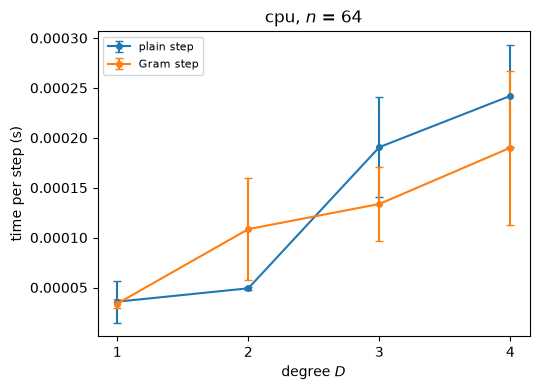

In [7]:
n_plot = 64  # size shown in the plots
fig, axs = plt.subplots(1, len(cfg.devices), figsize=(5.5 * len(cfg.devices), 4), squeeze=False)
for ax, device in zip(axs[0], cfg.devices):
    plots.plot_step_cost_vs_degree(res, device, n_plot, ax=ax)
fig.tight_layout()
for device in cfg.devices:
    for variant in ("matrix", "gram"):
        step_cost_table(res, device, variant)
        print()